# CelebA-HQ Diffusion Pipeline

This notebook implements a diffusion model pipeline for generating human faces using the CelebA-HQ 256x256 dataset.

We begin with dataset loading and visualization before moving to preprocessing and training.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("Notebook cwd:", Path.cwd())
print("Project root:", PROJECT_ROOT)

import matplotlib.pyplot as plt
import torch

from src.celeba_dataset import CelebAHQDataset

Notebook cwd: /scratch/juby/eee068-diffusion-face-generation/notebooks
Project root: /scratch/juby/eee068-diffusion-face-generation


## Dataset

We use the CelebA-HQ dataset (256×256 RGB face images) for training a diffusion model.

In [2]:
CELEBA_PATH = PROJECT_ROOT / "celeba_hq_256"

dataset = CelebAHQDataset(CELEBA_PATH)

print("Total images:", len(dataset))
print("Sample image size:", dataset[0]["images"].size)

Loaded 30000 images from /scratch/juby/eee068-diffusion-face-generation/celeba_hq_256
Total images: 30000
Sample image size: (256, 256)


## Data Inspection

We visualise a few samples to verify image quality and consistency before preprocessing.

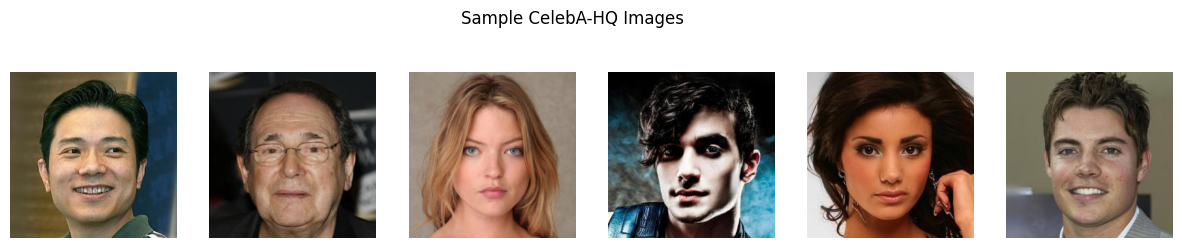

In [3]:
fig, axs = plt.subplots(1, 6, figsize=(15, 3))

for i in range(6):
    img = dataset[i]["images"]
    axs[i].imshow(img)
    axs[i].axis("off")

plt.suptitle("Sample CelebA-HQ Images")
plt.show()

## Train-Test Split

To evaluate model performance, we split the dataset into:
- Training set
- Test set

We use a fixed random seed to ensure reproducibility.

For this project:
- Training set: 2700 images
- Test set: 300 images

In [4]:
from torch.utils.data import random_split, Subset

subset_size = 3000
train_size = 2700
test_size = 300

project_dataset = Subset(dataset, range(subset_size))

train_dataset, test_dataset = random_split(
    project_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Project subset size:", len(project_dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Project subset size: 3000
Train size: 2700
Test size: 300


## Next Step: Preprocessing

The dataset currently returns raw PIL images. 
In the next stage, preprocessing will be applied including:
- Resizing to 128×128 for faster training while using the CelebA-HQ 256×256 dataset
- Normalization to [-1, 1]
- Data augmentation (horizontal flipping)

These transformations will be incorporated via PyTorch transforms and DataLoader.

In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader, Subset, random_split

FACE_SIZE = 256
BATCH_SIZE = 4

transform = transforms.Compose([
    transforms.Resize((FACE_SIZE, FACE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
        saturation=0.08,
        hue=0.015
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = CelebAHQDataset(CELEBA_PATH, transform=transform)

subset_size = 3000
train_size = 2700
test_size = 300

assert len(dataset) >= subset_size, f"Need at least 3000 images, found {len(dataset)}"

project_dataset = Subset(dataset, range(subset_size))

train_dataset, test_dataset = random_split(
    project_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Project subset size:", len(project_dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Loaded 30000 images from /scratch/juby/eee068-diffusion-face-generation/celeba_hq_256
Project subset size: 3000
Train size: 2700
Test size: 300
Train batches: 675
Test batches: 75


Batch shape: torch.Size([4, 3, 256, 256])
Min pixel value: -1.0
Max pixel value: 0.9843137264251709


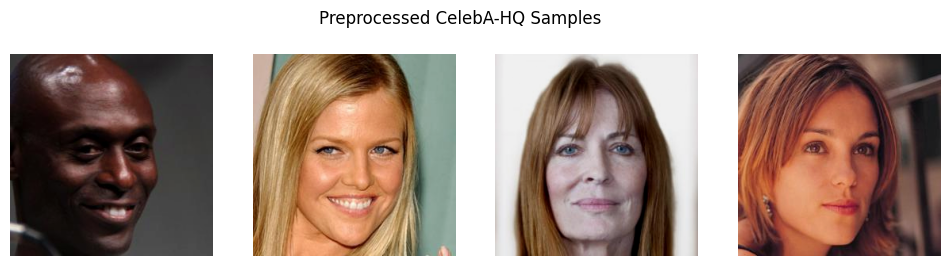

In [6]:
batch = next(iter(train_loader))
images = batch["images"][:6]

print("Batch shape:", batch["images"].shape)
print("Min pixel value:", batch["images"].min().item())
print("Max pixel value:", batch["images"].max().item())

num_show = min(6, images.shape[0])

fig, axs = plt.subplots(1, num_show, figsize=(3 * num_show, 3))

if num_show == 1:
    axs = [axs]

for i in range(num_show):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    axs[i].imshow(img)
    axs[i].axis("off")

plt.suptitle("Preprocessed CelebA-HQ Samples")
plt.show()

## DDPM U-Net Model and Noise Scheduler

This section sets up the denoising model used in the diffusion pipeline. A DDPM gradually adds Gaussian noise to clean images during the forward process, and the U-Net learns to predict the added noise at a given timestep. During generation, this learned denoising process is reversed to transform random noise into face images.

In [7]:
from diffusers import UNet2DModel, DDPMScheduler
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

face_model = UNet2DModel(
    sample_size=FACE_SIZE,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 256, 512, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(DEVICE)

noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2"
)

total_params = sum(p.numel() for p in face_model.parameters())
trainable_params = sum(p.numel() for p in face_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("DDPM timesteps:", noise_scheduler.config.num_train_timesteps)
print("Beta schedule:", noise_scheduler.config.beta_schedule)

Using device: cuda
Total parameters: 113,673,219
Trainable parameters: 113,673,219
DDPM timesteps: 1000
Beta schedule: squaredcos_cap_v2


## Forward Diffusion Noise Process

In DDPM training, Gaussian noise is gradually added to clean face images over multiple timesteps. At lower timesteps the image remains mostly clear, while at higher timesteps the image becomes almost pure noise.

The U-Net is trained to predict this added noise so that the reverse diffusion process can later reconstruct realistic faces from random noise.

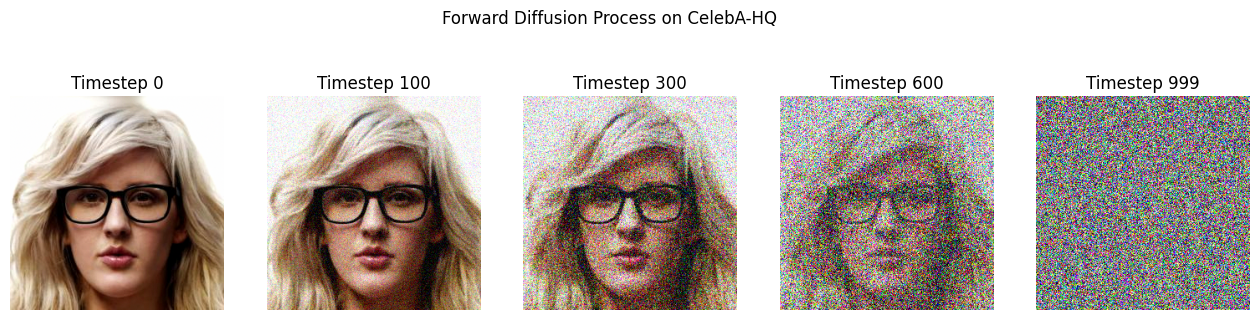

In [8]:
import matplotlib.pyplot as plt

sample_batch = next(iter(train_loader))
sample_images = sample_batch["images"].to(DEVICE)

noise_levels = [0, 100, 300, 600, 999]
image = sample_images[0:1]

fig, axs = plt.subplots(1, len(noise_levels), figsize=(16, 4))

for i, timestep in enumerate(noise_levels):

    noise = torch.randn_like(image)

    t = torch.tensor([timestep], device=DEVICE).long()

    noisy_image = noise_scheduler.add_noise(
        image,
        noise,
        t
    )

    img = noisy_image[0].detach().cpu().permute(1, 2, 0)

    img = (img * 0.5 + 0.5).clamp(0, 1)

    axs[i].imshow(img)

    axs[i].set_title(f"Timestep {timestep}")

    axs[i].axis("off")

plt.suptitle("Forward Diffusion Process on CelebA-HQ")
plt.show()

### Model Validation

Before training, the DDPM pipeline is validated by checking that:
- clean images,
- noisy images,
- predicted noise outputs

all maintain the same tensor dimensions.

This confirms that the U-Net architecture and scheduler are compatible with the CelebA-HQ dataset pipeline.

In [9]:
sample_batch = next(iter(train_loader))

sample_images = sample_batch["images"].to(DEVICE)

timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (sample_images.shape[0],),
    device=DEVICE
).long()

noise = torch.randn_like(sample_images)

noisy_images = noise_scheduler.add_noise(
    sample_images,
    noise,
    timesteps
)

with torch.no_grad():

    predicted_noise = face_model(
        noisy_images,
        timesteps
    ).sample

print("Clean image shape:", sample_images.shape)

print("Noisy image shape:", noisy_images.shape)

print("Predicted noise shape:", predicted_noise.shape)

Clean image shape: torch.Size([4, 3, 256, 256])
Noisy image shape: torch.Size([4, 3, 256, 256])
Predicted noise shape: torch.Size([4, 3, 256, 256])


## DDPM Setup Complete

The DDPM architecture, scheduler, and forward diffusion process have now been verified successfully. The model is ready for the training stage, where the U-Net will learn to predict Gaussian noise added to CelebA-HQ face images.

# Training Pipeline

This section trains the DDPM U-Net model to predict Gaussian noise added during the forward diffusion process.

The model learns to reverse the diffusion process by estimating the noise component from noisy face images sampled at random timesteps.

We use:
- Mean Squared Error (MSE) loss
- AdamW optimizer
- Random timestep sampling
- Noise prediction training objective

Training loss is tracked and visualized to evaluate convergence.

In [10]:
# Loss function and optimizer

from diffusers.optimization import get_cosine_schedule_with_warmup

criterion = torch.nn.MSELoss()

optimizer = torch.optim.AdamW(
    face_model.parameters(),
    lr=5e-5
)

num_epochs = 50

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(train_loader) * num_epochs,
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss function: MSELoss()
Optimizer: AdamW


# Loss function and optimizer

criterion = torch.nn.MSELoss()

optimizer = torch.optim.AdamW(
    face_model.parameters(),
    lr=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

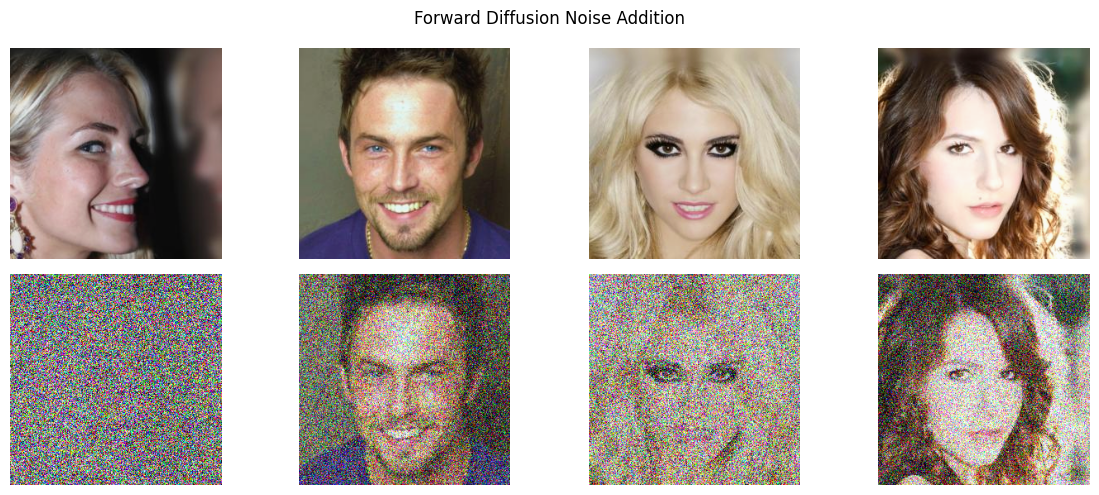

In [11]:
# Visualizing noisy image generation for training

sample_batch = next(iter(train_loader))
sample_images = sample_batch["images"].to(DEVICE)

num_show = min(6, sample_images.shape[0])

noise = torch.randn_like(sample_images[:num_show])

timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (num_show,),
    device=DEVICE
).long()

noisy_images = noise_scheduler.add_noise(
    sample_images[:num_show],
    noise,
    timesteps
)

fig, axs = plt.subplots(2, num_show, figsize=(3 * num_show, 5))

if num_show == 1:
    axs = axs.reshape(2, 1)

for i in range(num_show):
    clean_img = sample_images[i].detach().cpu().permute(1, 2, 0).numpy()
    clean_img = (clean_img * 0.5 + 0.5).clip(0, 1)

    noisy_img = noisy_images[i].detach().cpu().permute(1, 2, 0).numpy()
    noisy_img = (noisy_img * 0.5 + 0.5).clip(0, 1)

    axs[0, i].imshow(clean_img)
    axs[0, i].axis("off")

    axs[1, i].imshow(noisy_img)
    axs[1, i].axis("off")

axs[0, 0].set_ylabel("Original", fontsize=12)
axs[1, 0].set_ylabel("Noisy", fontsize=12)

plt.suptitle("Forward Diffusion Noise Addition")
plt.tight_layout()
plt.show()

## DDPM Training Loop

The training loop performs iterative denoising learning.

For every mini-batch:
- Gaussian noise is sampled
- Random timesteps are selected
- Noise is added using the scheduler
- The U-Net predicts the noise residual
- MSE loss is minimized using AdamW

Training loss is recorded after every epoch.

In [12]:
from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

training_losses = []

face_model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader)

    for batch in progress_bar:
        clean_images = batch["images"].to(DEVICE)

        noise = torch.randn_like(clean_images)
        batch_size = clean_images.shape[0]

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=DEVICE
        ).long()

        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        optimizer.zero_grad()

        with autocast("cuda"):
            noise_prediction = face_model(noisy_images, timesteps).sample
            loss = criterion(noise_prediction, noise)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

        epoch_loss += loss.item()
        progress_bar.set_description(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

    average_loss = epoch_loss / len(train_loader)
    training_losses.append(average_loss)

    print(f"Epoch {epoch+1} Average Loss: {average_loss:.4f}")

    if (epoch + 1) % 25 == 0:

        torch.save({

            "epoch": epoch + 1,

            "model_state_dict": face_model.state_dict(),

            "optimizer_state_dict": optimizer.state_dict(),

            "training_losses": training_losses,

            "image_size": FACE_SIZE,

            "batch_size": BATCH_SIZE,

            "learning_rate": 1e-4,

        }, PROJECT_ROOT / "results" / f"ddpm_face_model_{epoch+1}epochs_256_cosine_jitter.pth")

        print(f"Checkpoint saved for epoch {epoch+1}")

   

  0%|          | 0/675 [00:00<?, ?it/s]

Epoch 1 Average Loss: 0.1965


  0%|          | 0/675 [00:00<?, ?it/s]

Epoch 2 Average Loss: 0.0426


  0%|          | 0/675 [00:00<?, ?it/s]

...

Epoch 48 Average Loss: 0.0170


  0%|          | 0/675 [00:00<?, ?it/s]

Epoch 49 Average Loss: 0.0181


  0%|          | 0/675 [00:00<?, ?it/s]

Epoch 50 Average Loss: 0.0183
Checkpoint saved for epoch 50


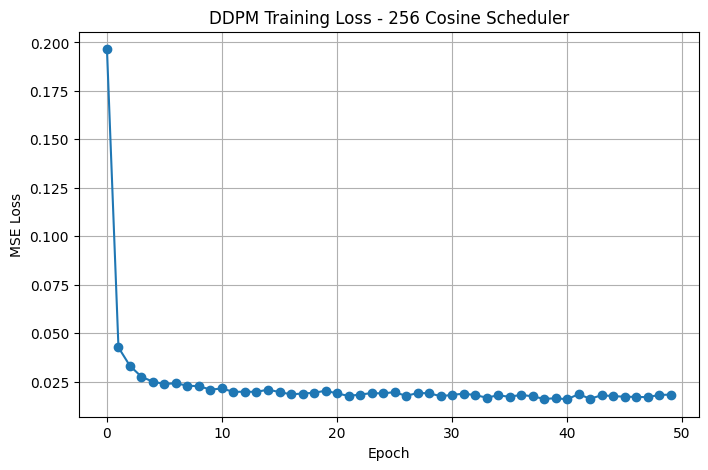

Loss curve saved to: /scratch/juby/eee068-diffusion-face-generation/results/training_loss_256_cosine_jitter.png


In [13]:
plt.figure(figsize=(8, 5))
plt.plot(training_losses, marker="o")
plt.title("DDPM Training Loss - 256 Cosine Scheduler")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

loss_path = PROJECT_ROOT / "results" / "training_loss_256_cosine_jitter.png"
plt.savefig(loss_path, dpi=300)
plt.show()

print("Loss curve saved to:", loss_path)

  0%|          | 0/500 [00:00<?, ?it/s]

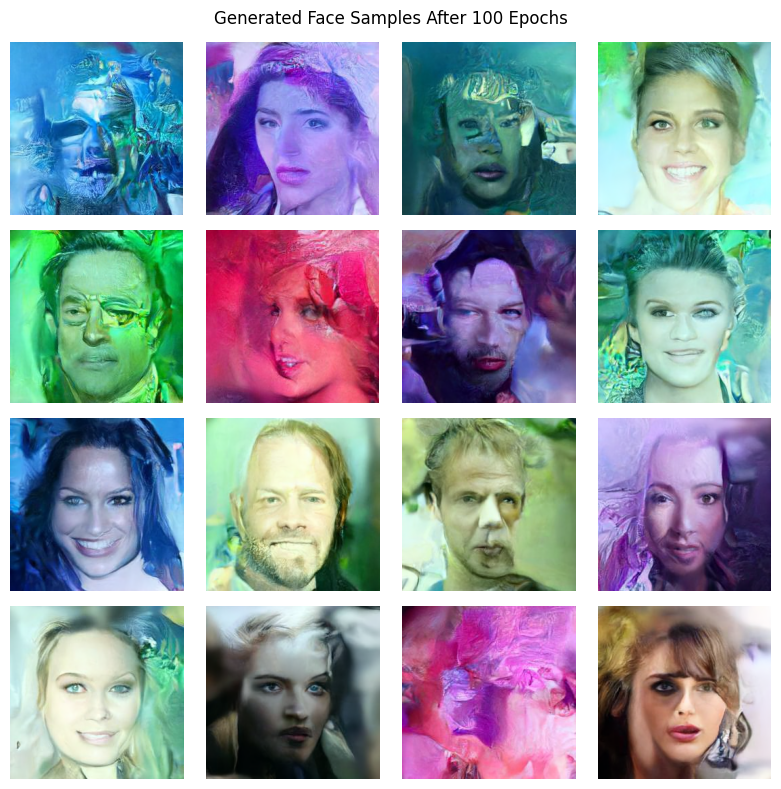

In [14]:
from diffusers import DDPMPipeline

face_model.eval()

preview_pipeline = DDPMPipeline(
    unet=face_model,
    scheduler=noise_scheduler
).to(DEVICE)

with torch.no_grad():
    preview_images = preview_pipeline(
        batch_size=16,
        generator=torch.manual_seed(42),
        num_inference_steps=500
    ).images

fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for i, img in enumerate(preview_images):
    axs[i // 4, i % 4].imshow(img)
    axs[i // 4, i % 4].axis("off")

plt.suptitle("Generated Face Samples After 100 Epochs")
plt.tight_layout()
plt.show()

# Generation and Evaluation

This section evaluates the trained DDPM model by generating 300 synthetic face images and comparing them with the 300 held-out CelebA-HQ test images.

The evaluation includes:
- Generated sample grid
- Real vs generated image comparison
- Saving generated images
- Computing FID between generated and test images

In [16]:
# Generate and save 300 images for evaluation

from diffusers import DDPMPipeline
from pathlib import Path

generated_dir = PROJECT_ROOT / "results" / "generated_300_256_cosine_jitter"
generated_dir.mkdir(parents=True, exist_ok=True)

face_model.eval()

eval_pipeline = DDPMPipeline(
    unet=face_model,
    scheduler=noise_scheduler
).to(DEVICE)

num_generated_images = 300
batch_generate_size = 10
generated_count = 0

for batch_start in range(0, num_generated_images, batch_generate_size):

    with torch.no_grad():
        generated_images = eval_pipeline(
            batch_size=batch_generate_size,
            generator=torch.manual_seed(42 + batch_start),
            num_inference_steps=250
        ).images

    for img in generated_images:
        if generated_count >= num_generated_images:
            break

        img.save(generated_dir / f"generated_{generated_count:03d}.png")
        generated_count += 1

print("Generated images saved:", generated_count)
print("Saved to:", generated_dir)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

Generated images saved: 300
Saved to: /scratch/juby/eee068-diffusion-face-generation/results/generated_300_256_cosine_jitter


In [17]:
# Save 300 real test images for FID comparison

real_dir = PROJECT_ROOT / "results" / "real_test_300_256_jitter"
real_dir.mkdir(parents=True, exist_ok=True)

real_count = 0

for batch in test_loader:
    images = batch["images"]

    for img_tensor in images:
        if real_count >= 300:
            break

        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)

        plt.imsave(real_dir / f"real_{real_count:03d}.png", img)
        real_count += 1

    if real_count >= 300:
        break

print("Real test images saved:", real_count)
print("Saved to:", real_dir)

Real test images saved: 300
Saved to: /scratch/juby/eee068-diffusion-face-generation/results/real_test_300_256_jitter


## Real vs Generated Face Comparison

A visual comparison is shown between held-out real CelebA-HQ test images and images generated by the trained DDPM model.

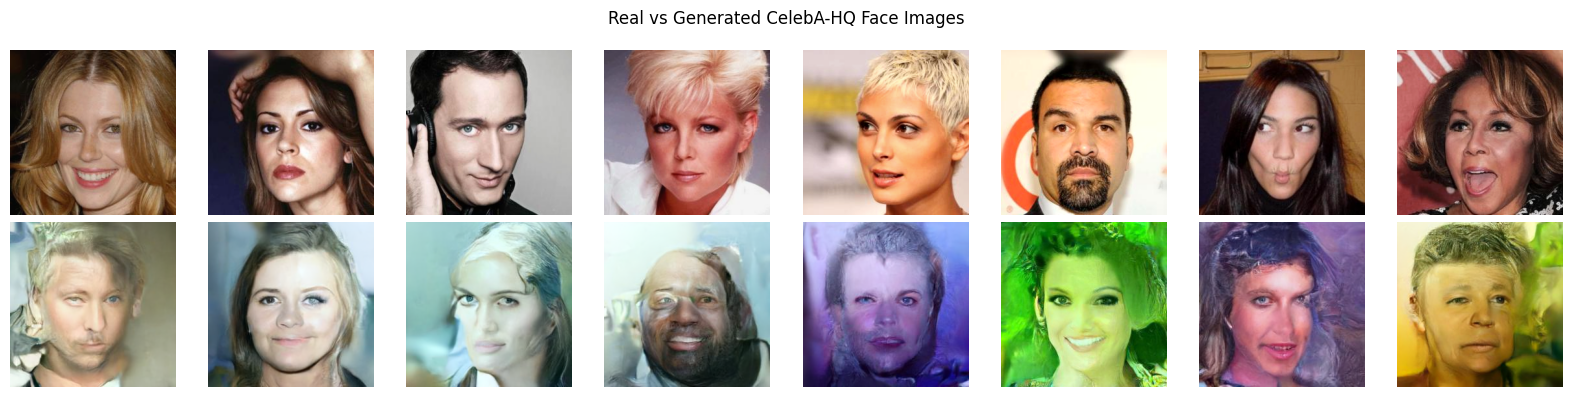

Comparison grid saved to: /scratch/juby/eee068-diffusion-face-generation/results/real_vs_generated_comparison_256_cosine_jitter.png


In [19]:
# Real vs generated comparison grid

from PIL import Image
import random

real_files = sorted(real_dir.glob("*.png"))
generated_files = sorted(generated_dir.glob("*.png"))

sample_indices = random.sample(range(300), 8)

fig, axs = plt.subplots(2, 8, figsize=(16, 4))

for i, idx in enumerate(sample_indices):
    real_img = Image.open(real_files[idx])
    gen_img = Image.open(generated_files[idx])

    axs[0, i].imshow(real_img)
    axs[0, i].axis("off")

    axs[1, i].imshow(gen_img)
    axs[1, i].axis("off")

axs[0, 0].set_ylabel("Real", fontsize=12)
axs[1, 0].set_ylabel("Generated", fontsize=12)

plt.suptitle("Real vs Generated CelebA-HQ Face Images")
plt.tight_layout()

comparison_path = PROJECT_ROOT / "results" / "real_vs_generated_comparison_256_cosine_jitter.png"
plt.savefig(comparison_path, dpi=300)
plt.show()

print("Comparison grid saved to:", comparison_path)

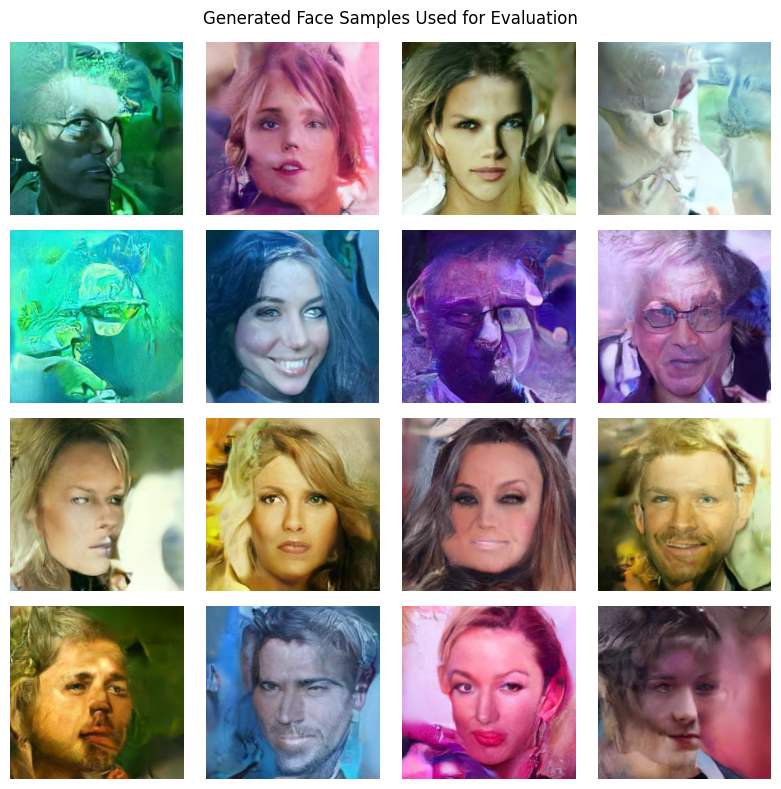

Generated grid saved to: /scratch/juby/eee068-diffusion-face-generation/results/generated_faces_grid_256_cosine_jitter.png


In [20]:
# Preview grid of generated images

generated_files = sorted(generated_dir.glob("*.png"))

fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for i in range(16):
    img = Image.open(generated_files[i])
    axs[i // 4, i % 4].imshow(img)
    axs[i // 4, i % 4].axis("off")

plt.suptitle("Generated Face Samples Used for Evaluation")
plt.tight_layout()

generated_grid_path = PROJECT_ROOT / "results" / "generated_faces_grid_256_cosine_jitter.png"
plt.savefig(generated_grid_path, dpi=300)
plt.show()

print("Generated grid saved to:", generated_grid_path)

## FID Evaluation

The Fréchet Inception Distance measures similarity between the distribution of generated images and real test images.

Lower FID indicates generated images are closer to the real CelebA-HQ test distribution.

In [21]:
# Compute FID score between generated images and real test images

from cleanfid import fid

fid_score = fid.compute_fid(
    str(real_dir),
    str(generated_dir),
    mode="clean",
    num_workers=0
)

print("FID score:", fid_score)

compute FID between two folders
Found 300 images in the folder /scratch/juby/eee068-diffusion-face-generation/results/real_test_300_256_jitter


FID real_test_300_256_jitter : 100%|██████████| 10/10 [00:02<00:00,  3.40it/s]


Found 300 images in the folder /scratch/juby/eee068-diffusion-face-generation/results/generated_300_256_cosine_jitter


FID generated_300_256_cosine_jitter : 100%|██████████| 10/10 [00:02<00:00,  3.65it/s]


FID score: 114.43401328924296


In [22]:
# Save evaluation summary

summary_path = PROJECT_ROOT / "results" / "evaluation_summary_256_cosine_jitter.txt"

with open(summary_path, "w") as f:
    f.write("DDPM CelebA-HQ Evaluation Summary\n")
    f.write("---------------------------------\n")
    f.write(f"Training images: {len(train_dataset)}\n")
    f.write(f"Test images: {len(test_dataset)}\n")
    f.write(f"Generated images: {num_generated_images}\n")
    f.write(f"Image size: {FACE_SIZE}x{FACE_SIZE}\n")
    f.write(f"FID score: {fid_score}\n")

print("Evaluation summary saved to:", summary_path)

Evaluation summary saved to: /scratch/juby/eee068-diffusion-face-generation/results/evaluation_summary_256_cosine_jitter.txt
